<a href="https://colab.research.google.com/github/drm69/PCVK25_3F_12/blob/main/Week9_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install pytesseract

In [4]:
import cv2
import numpy as np
import pytesseract
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

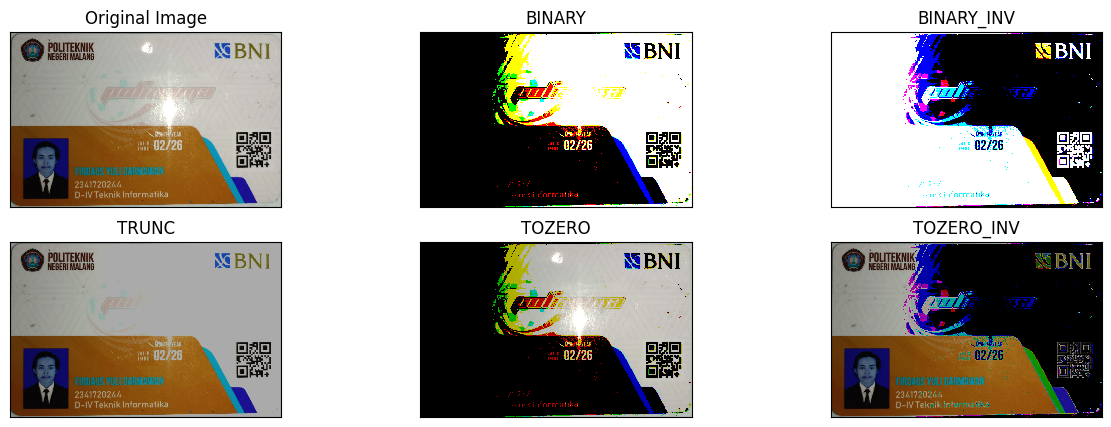

In [8]:
filename = ('/content/drive/MyDrive/BERKAS PENTING/KTM.jpg')
img = cv2.imread(filename)

if img is None:
    print(f"Error: Could not load image from {filename}")
else:
    thresh1 = cv2.imread(filename)
    thresh2 = cv2.imread(filename)
    thresh3 = cv2.imread(filename)
    thresh4 = cv2.imread(filename)
    thresh5 = cv2.imread(filename)
    thresh = 170 #nilai Threshold yang ditentukan
    #1. thresh1 jika pixel di img>127, maka thresh1 bernilai 1(putih) selain itu bernilai 0(hitam)
    thresh1[img>thresh] = 255 #tanpa library
    thresh1[img<=thresh] = 0
    #2. thresh2 adalah binary threshold inverse
    thresh2 = 255 - thresh1 #tanpa library
    #3. Threshold Truncate
    thresh3[img>thresh] = thresh #tanpa library
    #4. Threshold Tozero
    thresh4[img<=thresh] = 0 #tanpa library
    #5. Threshold Tozero Inverse
    thresh5[img>thresh] = 0 #tanpa library
    titles = ['Original Image','BINARY','BINARY_INV','TRUNC', 'TOZERO', 'TOZERO_INV']
    images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]
    plt.figure(figsize = (15,5))
    for i in range(len(images)):
        plt.subplot(2,3,i+1),plt.imshow(images[i],'gray', interpolation='nearest')
        plt.title(titles[i])
        plt.xticks([]),plt.yticks([])
    plt.show()

167


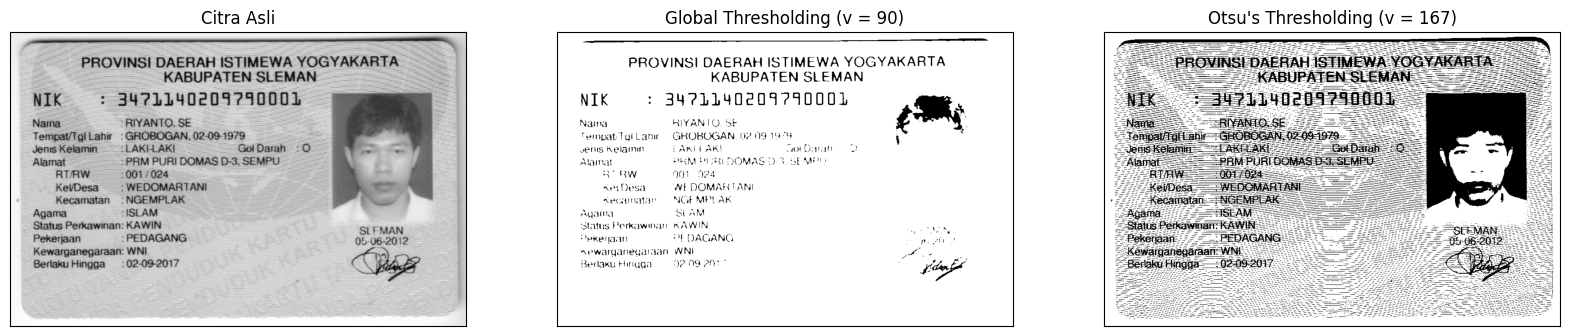

In [9]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

filename = ('/content/drive/MyDrive/images/ktp.png')
img = cv2.imread(filename, 0)
blur = cv2.GaussianBlur(img, (5, 5), 0)

def otsu(gray):
    pixel_number = gray.shape[0] * gray.shape[1]
    mean_weight = 1.0 / pixel_number
    his, bins = np.histogram(gray, np.arange(0, 257))
    final_thresh = -1
    final_value = -1
    intensity_arr = np.arange(256)

    for t in bins[1:-1]:
        pcb = np.sum(his[:t])
        pcf = np.sum(his[t:])
        Wb = pcb * mean_weight
        Wf = pcf * mean_weight

        mub = np.sum(intensity_arr[:t] * his[:t]) / float(pcb)
        muf = np.sum(intensity_arr[t:] * his[t:]) / float(pcf)

        value = Wb * Wf * (mub - muf) ** 2
        if value > final_value:
            final_thresh = t
            final_value = value

    final_img = gray.copy()
    print(final_thresh)
    final_img[gray > final_thresh] = 255
    final_img[gray <= final_thresh] = 0
    return final_img, final_thresh

otsu_biner, otsu_thresh = otsu(img)
x = "Otsu's Thresholding (v = " + str(otsu_thresh) + ")"
ret, th1 = cv2.threshold(blur, 90, 255, cv2.THRESH_BINARY)
# ret, th2 = cv2.threshold(blur, thresh, 255, cv2.THRESH_BINARY)

titles = ['Citra Asli', 'Global Thresholding (v = 90)', x]
citra3 = [blur, th1, otsu_biner]

plt.figure(figsize=(20, 15))
for i in range(len(citra3)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(citra3[i], 'gray')
    plt.title(titles[i])
    plt.xticks([])
    plt.yticks([])

plt.show()

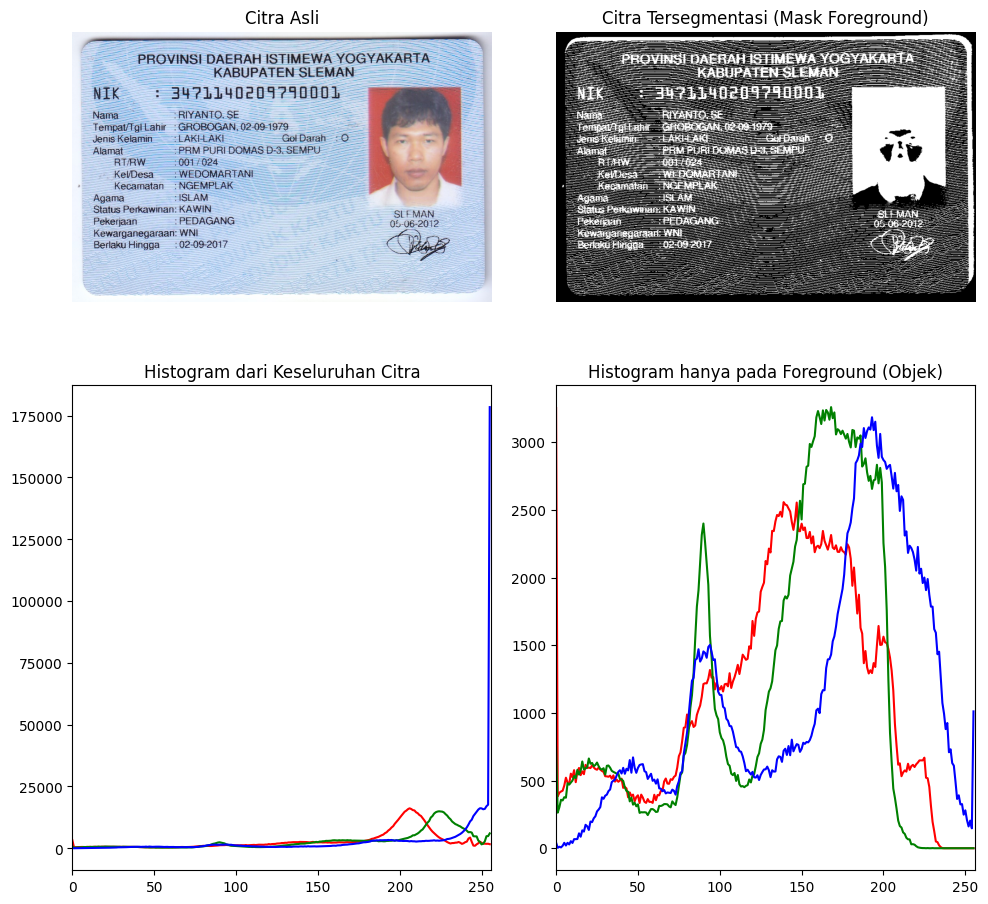

In [10]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

# === 1. Baca gambar ===
filename = '/content/drive/MyDrive/images/ktp.png'
img = cv.imread(filename)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

# === 2. Segmentasi menggunakan threshold invers ===
ret3, mask = cv.threshold(img_gray, 200, 255, cv.THRESH_BINARY_INV)

# === 3. Tampilkan citra asli dan hasil segmentasi ===
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.imshow(img)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(mask, 'gray')
plt.title('Citra Tersegmentasi (Mask Foreground)')
plt.axis('off')

# === 4. Hitung dan tampilkan histogram ===
color = ('r', 'g', 'b')
for i, col in enumerate(color):
    # Histogram seluruh citra
    hist0 = cv.calcHist([img], [i], None, [256], [0, 256])
    plt.subplot(2, 2, 3)
    plt.plot(hist0, color=col)
    plt.title('Histogram dari Keseluruhan Citra')
    plt.xlim([0, 256])

    # Histogram hanya untuk foreground (menggunakan mask)
    hist1 = cv.calcHist([img], [i], mask, [256], [0, 256])
    plt.subplot(2, 2, 4)
    plt.plot(hist1, color=col)
    plt.title('Histogram hanya pada Foreground (Objek)')
    plt.xlim([0, 256])

plt.tight_layout()
plt.show()

Warna cluster (BGR): [[207 224 246]
 [ 52  53  72]
 [147 152 175]]


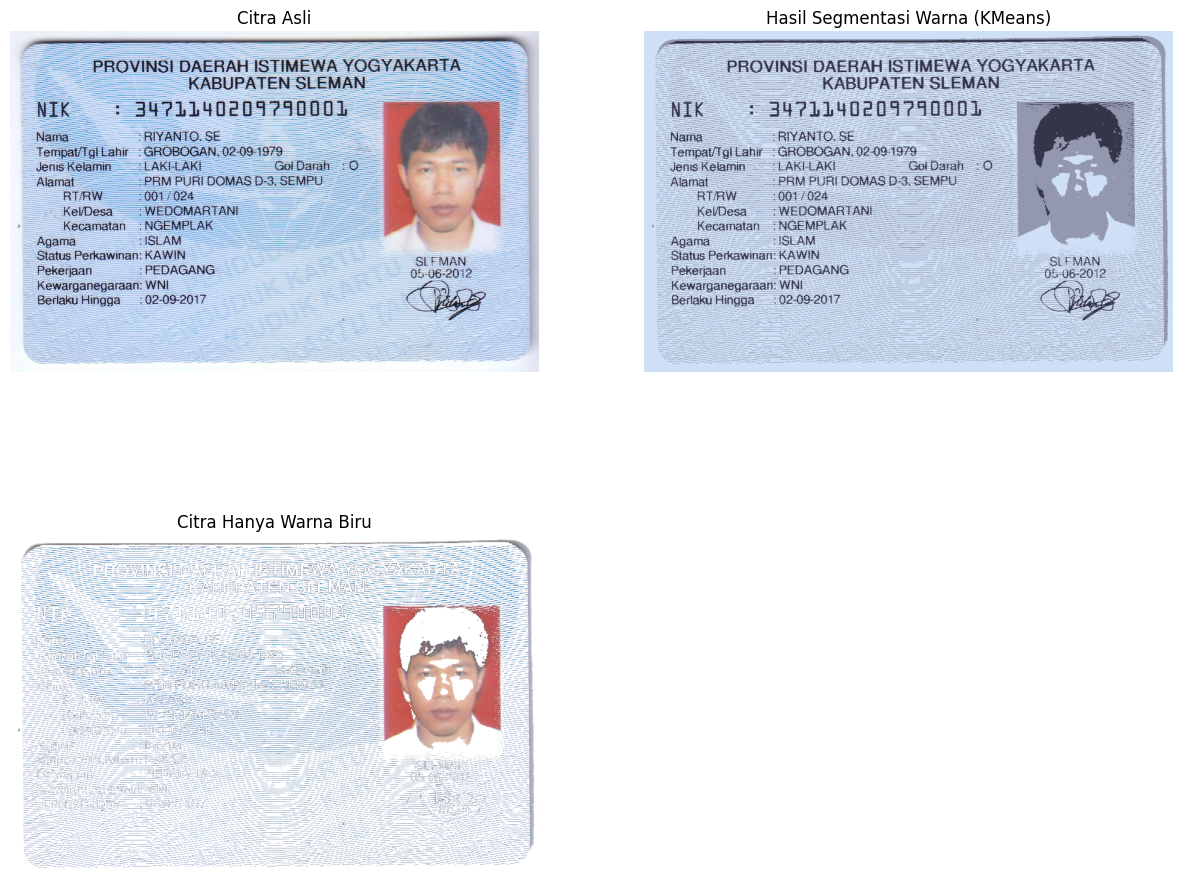

In [13]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

# === 1. Baca gambar dan ubah ke RGB ===
filename = '/content/drive/MyDrive/images/ktp.png'
img = cv.imread(filename)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# === 2. Ubah menjadi array 2D (flatten) ===
pixel_values = img.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# === 3. Tentukan kriteria berhenti untuk KMeans ===
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 150, 0.1)

# === 4. Tentukan jumlah cluster warna (k) ===
k = 3
_, labels, centers = cv.kmeans(pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

# === 5. Ubah pusat cluster ke bentuk integer (0–255) ===
centers = np.uint8(centers)
labels = labels.flatten()
print("Warna cluster (BGR):", centers)

# === 6. Bentuk ulang hasil segmentasi ke ukuran gambar asli ===
segmented_image = centers[labels.flatten()]
segmented_image = segmented_image.reshape(img.shape)

# === 7. Masking hanya warna biru (cluster ke-2) ===
masked_image = np.copy(img)
masked_image0 = masked_image.reshape((-1, 3))
masked_image0[labels != 2] = [255, 255, 255]
masked_image0 = masked_image0.reshape(img.shape)

# === 8. Tampilkan hasil ===
plt.figure(figsize=(15, 12))
plt.subplot(2, 2, 1), plt.imshow(img)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(2, 2, 2), plt.imshow(segmented_image)
plt.title('Hasil Segmentasi Warna (KMeans)')
plt.axis('off')

plt.subplot(2, 2, 3), plt.imshow(masked_image0)
plt.title('Citra Hanya Warna Biru')
plt.axis('off')

plt.show()

In [14]:
!pip install pytesseract
!sudo apt-get install tesseract-ocr-ind

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tesseract-ocr-ind
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 537 kB of archives.
After this operation, 1,138 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-ind all 1:4.00~git30-7274cfa-1.1 [537 kB]
Fetched 537 kB in 1s (791 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package tesseract-ocr-ind.
(Reading databa